# Clase 08 — Exploración Inicial y Visualización Básica

> Notebook de práctica. Ejecutá las celdas a medida que avanzás en el artículo.

¡Bienvenido al equipo de datos de **TechMarket**!

La empresa acaba de finalizar una migración completa de su sistema de ventas hacia una nueva plataforma. Como ocurre en cualquier proyecto de migración, nadie sabe con certeza si toda la información llegó correctamente. Durante este laboratorio realizarás exactamente el mismo proceso que seguiría un analista de datos en una empresa real al recibir un conjunto de datos por primera vez.

Cada misión representa una solicitud realizada por distintos miembros de la empresa. No se espera que conozcas todas las respuestas de memoria. Utiliza las herramientas aprendidas durante la clase para investigar el dataset y tomar decisiones.


## Escenario

La empresa almacena información de sus productos en una base de datos SQLite. El equipo de ingeniería ya realizó la consulta y cargó los datos en un DataFrame llamado `df`.

In [3]:
import sqlite3
import pandas as pd

conexion = sqlite3.connect("ventas.db")

df = pd.read_sql(
    "SELECT * FROM productos",
    conexion
)
print(df)

      id            nombre   categoria     precio  stock
0      1       Mouse Gamer      gaming  260318.02     31
1      2           Headset      gaming   33167.77     54
2      3          Notebook        tech  197752.04     91
3      4       Auriculares        tech  283872.37      0
4      5        Biblioteca     muebles   56951.39     97
..   ...               ...         ...        ...    ...
245  246           Monitor        tech  105639.86    100
246  247        Archivador     oficina   16098.38     43
247  248     Teclado Gamer      gaming   59299.78    106
248  249  Soporte Notebook  accesorios   18161.27     46
249  250        Biblioteca     muebles  264079.73    100

[250 rows x 5 columns]


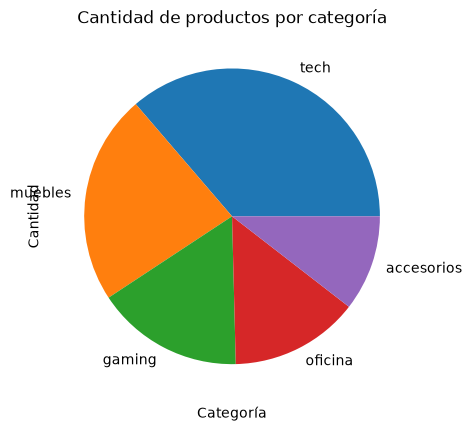

In [18]:
import matplotlib.pyplot as plt
df["categoria"].value_counts().plot(kind="pie")
plt.title("Cantidad de productos por categoría")
plt.xlabel("Categoría")
plt.ylabel("Cantidad")
plt.show()

A partir de este momento trabajarás únicamente con el DataFrame.

### Ejercicio 1 — ¿Llegaron todos los datos?

Durante la madrugada se ejecutó una consulta SQL para obtener el catálogo completo de productos que actualmente comercializa la empresa. Antes de comenzar cualquier análisis, tu supervisor quiere asegurarse de que la consulta SQL devolvió una cantidad razonable de información.

**Tu tarea**

Determina:

- ¿Cuántos registros recibió el DataFrame?
- ¿Cuántas columnas contiene?

In [ ]:
print(df)

#250 filas por 5 columnas

      id            nombre   categoria     precio  stock
0      1       Mouse Gamer      gaming  260318.02     31
1      2           Headset      gaming   33167.77     54
2      3          Notebook        tech  197752.04     91
3      4       Auriculares        tech  283872.37      0
4      5        Biblioteca     muebles   56951.39     97
..   ...               ...         ...        ...    ...
245  246           Monitor        tech  105639.86    100
246  247        Archivador     oficina   16098.38     43
247  248     Teclado Gamer      gaming   59299.78    106
248  249  Soporte Notebook  accesorios   18161.27     46
249  250        Biblioteca     muebles  264079.73    100

[250 rows x 5 columns]


> **Pregunta para reflexionar**

¿Por qué verificar el tamaño del dataset debería ser una de las primeras tareas de cualquier analista de datos?

### Ejercicio 2 — Primera inspección visual

Ahora debes comprobar rápidamente que los datos realmente representan productos. Muchas veces una consulta SQL devuelve columnas equivocadas, datos mezclados o incluso tablas incorrectas.

**Consigna:** Realiza una inspección visual del DataFrame y observa:

- nombres de columnas
- primeras filas
- si los datos parecen coherentes


(250, 5)
   id       nombre categoria     precio  stock
0   1  Mouse Gamer    gaming  260318.02     31
1   2      Headset    gaming   33167.77     54
2   3     Notebook      tech  197752.04     91
3   4  Auriculares      tech  283872.37      0
4   5   Biblioteca   muebles   56951.39     97
<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         250 non-null    int64  
 1   nombre     250 non-null    str    
 2   categoria  248 non-null    str    
 3   precio     246 non-null    float64
 4   stock      250 non-null    int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 9.9 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         250 non-null    int64  
 1   nombre     250 non-null    str    
 2   categoria  248 

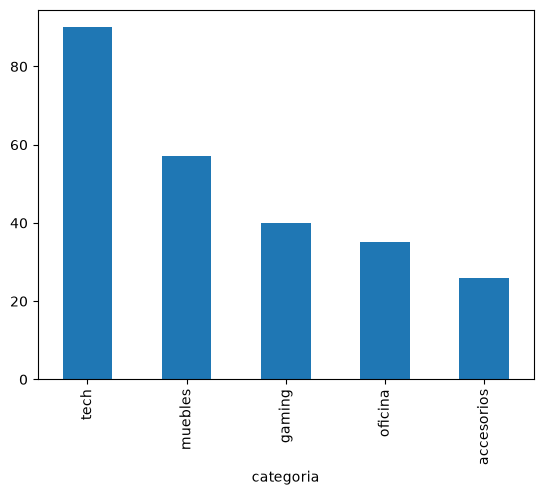

id           0
nombre       0
categoria    2
precio       4
stock        0
dtype: int64


In [35]:
df = pd.read_sql(
    "SELECT * FROM productos",
    conexion
    )
print(df.shape)
print(df.head())
print(df.info())
print(df.info())
print(df.describe())
print(df["categoria"].value_counts())
df["categoria"].value_counts().plot(kind = "bar")
plt.show()


#REVISANDO LOS NULOS
#HASTA AHORA ENCONTRE NULOS EN LA CATEGORIA Y EN EL PRECIO, PERO NO EN EL NOMBRE
print(df.isna().sum())
#lo de arriba suma por categoria solo los valores nulos

array([], dtype=int64)

> **Piensa como analista**

¿Detectas algo que te haga desconfiar del dataset?

### Ejercicio 3 — Revisando el final de la carga

Durante algunas migraciones los últimos registros pueden quedar incompletos debido a interrupciones durante la exportación.

**Consigna:** Inspecciona las últimas filas del DataFrame. Busca posibles señales de problemas como:

- registros incompletos;
- valores vacíos;
- datos extraños.

In [36]:
df_tail = df.tail(10)
print(df_tail)
#243  244           Monitor        tech        NaN     54


      id            nombre   categoria     precio  stock
240  241           Headset      gaming  306028.04     42
241  242          Pendrive  accesorios  338790.69     89
242  243       Mouse Gamer      gaming  110424.91     48
243  244           Monitor        tech        NaN     54
244  245           Teclado        tech  121581.12     98
245  246           Monitor        tech  105639.86    100
246  247        Archivador     oficina   16098.38     43
247  248     Teclado Gamer      gaming   59299.78    106
248  249  Soporte Notebook  accesorios   18161.27     46
249  250        Biblioteca     muebles  264079.73    100


### Ejercicio 4 — ¿Qué tipo de información recibimos?

Antes de realizar cálculos necesitas conocer qué representa cada columna. No tendría sentido calcular promedios sobre texto ni contar frecuencias de valores numéricos sin comprender su significado.

**Consigna:** Obtén un resumen de la estructura del DataFrame e identifica:

- nombres de columnas;
- tipos de datos;
- cantidad de valores no nulos.

In [45]:
print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         250 non-null    int64  
 1   nombre     250 non-null    str    
 2   categoria  248 non-null    str    
 3   precio     246 non-null    float64
 4   stock      250 non-null    int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 9.9 KB
None


> **Pregunta para reflexionar**

¿Por qué resulta peligroso asumir el tipo de una columna sin verificarlo?
porque se podria querer realizar operaciones en columnas de tipo string (u objet)

### Ejercicio 5 — Buscando valores sospechosos

El gerente financiero cree que algunos productos podrían haberse cargado con precios incorrectos. No quiere revisar miles de registros manualmente.

**Consigna:** Realiza una exploración estadística de las columnas numéricas e intenta responder:

- ¿Cuál es el precio mínimo?
- ¿Cuál es el máximo?
- ¿El promedio parece razonable?
- ¿Observas algún valor que llame la atención?

In [ ]:
normalize =  (df["categoria"].value_counts(normalize = True)*100).round(2)
print (normalize)

print(df.describe())

#el precio maximo es altisimo, siendo de 2.500.000
#precio tiene 246 existencias no null, lo que hace que haya un faltante de 4 precios
#el mean de precio es de 1.892422 mientras eu el mid (50%) es de 1.849493 ,
#lo que indica que hay un precio muy alto que hace que el promedio suba mucho, 
#pero la mediana es mucho mas baja, lo que indica que la mayoria de los precios son bajos,
#y hay unos pocos precios muy altos que hacen subir el promedio


categoria
tech          36.29
muebles       22.98
gaming        16.13
oficina       14.11
accesorios    10.48
Name: proportion, dtype: float64
               id        precio       stock
count  250.000000  2.460000e+02  250.000000
mean   125.500000  1.892422e+05   59.024000
std     72.312977  1.792635e+05   35.311571
min      1.000000  4.230350e+03   -2.000000
25%     63.250000  9.113853e+04   28.000000
50%    125.500000  1.849493e+05   60.000000
75%    187.750000  2.700179e+05   91.750000
max    250.000000  2.500000e+06  120.000000


### Ejercicio 6 — Entendiendo el catálogo

El director comercial quiere conocer cómo está distribuido el catálogo de productos.

**Consigna:** Genera un resumen que responda:

- ¿Cuántos productos existen por categoría?
- ¿Cuál es la categoría más grande?
- ¿Cuál es la menos representada?

In [64]:
print(df["categoria"].value_counts())

categoria
tech          90
muebles       57
gaming        40
oficina       35
accesorios    26
Name: count, dtype: int64


### Ejercicio 7 — ¿Qué porcentaje representa cada categoría?

Las cantidades son útiles, pero la dirección prefiere trabajar con porcentajes.

**Consigna:** Calcula qué porcentaje del catálogo pertenece a cada categoría.

In [67]:
print(df["categoria"].value_counts(normalize = True))

categoria
tech          0.362903
muebles       0.229839
gaming        0.161290
oficina       0.141129
accesorios    0.104839
Name: proportion, dtype: float64


> **Pregunta para reflexionar**

¿Por qué los porcentajes suelen ser más útiles que los valores absolutos cuando se comparan empresas de distintos tamaños?


### Ejercicio 8 — Preparando una reunión ejecutiva

Mañana habrá una reunión con la dirección y nadie quiere leer una tabla con números.

**Consigna:** Construye un gráfico de barras que permita visualizar rápidamente la cantidad de productos por categoría.


Text(0, 0.5, 'Cantidad de productos')

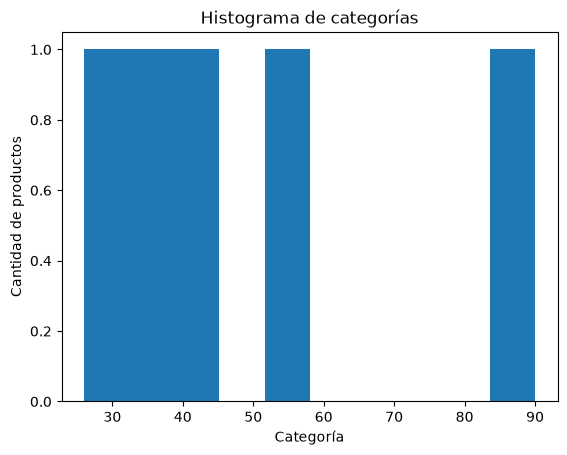

In [72]:
df["categoria"].value_counts().plot(kind = "hist")
plt.title("Histograma de categorías")
plt.xlabel("Categoría")
plt.ylabel("Cantidad de productos")

### Ejercicio 9 — Un gráfico listo para presentar


El gráfico anterior será incorporado a un informe ejecutivo. Debe poder entenderse sin necesidad de explicaciones adicionales.

**Consigna:** Mejora el gráfico agregando:

- título;
- nombre del eje X;
- nombre del eje Y.

In [ ]:
df["categoria"].value_counts().plot(kind = "hist")
plt.title("Histograma de categorías")
plt.xlabel("Categoría")
plt.ylabel("Cantidad de productos")
plt.show()

### Ejercicio 10 — Tu primer informe de exploración

Has terminado la revisión inicial del dataset.Antes de entregarlo al resto del equipo debes elaborar un pequeño informe técnico.

**Consigna:** Responde las siguientes preguntas utilizando toda la información obtenida durante las misiones anteriores.

1. ¿Cuántos registros contiene el dataset?

2. ¿Cuántas variables fueron recibidas?

3. ¿Existen columnas con datos faltantes?

4. ¿Qué tipos de datos predominan?

5. ¿Cuál es la categoría con mayor cantidad de productos?

6. ¿Observaste valores que podrían requerir una limpieza posterior?

7. ¿Consideras que el dataset está listo para comenzar un análisis más profundo? Justifica tu respuesta.


In [ ]:
df.columns
#1250 registros
#1242
#string
#tech
#si, limpieza, correccion o datos faltantes
#no, aun hay que pulir algunos registros


Index(['id', 'nombre', 'categoria', 'precio', 'stock'], dtype='str')